<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Autocomplete and Autocorrect Data Analytics**
Exploring the efficiency and accuracy of autocomplete and autocorrect algorithms in natural
language processing (NLP) through this data analytics project. The objective is to enhance user
experience and text prediction by analyzing large datasets and implementing or optimizing
autocomplete and autocorrect functionalities.

In [1]:
!pip install nltk textblob pyspellchecker --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 37.6 MB/s eta 0:00:00


**Importing Libraries and NLTK dataset**

In [5]:
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict, Counter
from nltk.util import ngrams
from nltk.corpus import brown, words
from textblob import TextBlob
from spellchecker import SpellChecker
nltk.download("brown")
nltk.download("words")
nltk.download("punkt")
nltk.download("punkt_tab")
# Loading all sentences from Brown corpus
sentences = brown.sents()
all_words  = [w.lower() for w in brown.words()]
print("Total words in corpus:", len(all_words))
print("Total sentences:      ", len(list(sentences)))
print("Sample words:", all_words[:10])

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Total words in corpus: 1161192
Total sentences:       57340
Sample words: ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of']


**Cleaning and preprocessing text**

In [6]:
def clean_text(word_list):
    # Keep only alphabetic words, lowercase
    return [w.lower() for w in word_list if w.isalpha()]

clean_words = clean_text(brown.words())
print("Words before cleaning:", len(all_words))
print("Words after cleaning: ", len(clean_words))
print("Sample:", clean_words[:15])

Words before cleaning: 1161192
Words after cleaning:  981716
Sample: ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no']


**Word Frequency Analysis**

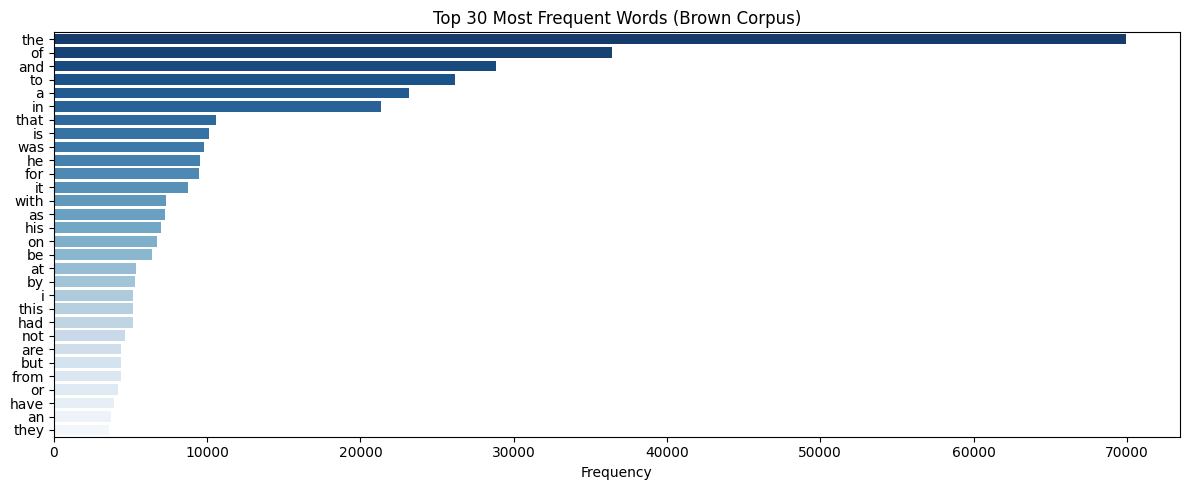

In [7]:
word_freq = Counter(clean_words)
top30 = word_freq.most_common(30)
words_list  = [w for w, c in top30]
counts_list = [c for w, c in top30]
plt.figure(figsize=(12, 5))
sns.barplot(x=counts_list, y=words_list, palette='Blues_r')
plt.title('Top 30 Most Frequent Words (Brown Corpus)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

****

**Word Length Distribution**

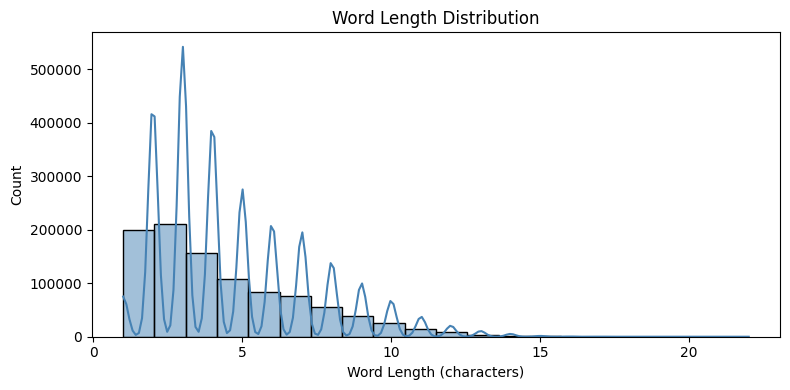

Average word length: 4.68


In [8]:
word_lengths = [len(w) for w in clean_words]
plt.figure(figsize=(8, 4))
sns.histplot(word_lengths, bins=20, kde=True, color='steelblue')
plt.title('Word Length Distribution')
plt.xlabel('Word Length (characters)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Average word length:", round(np.mean(word_lengths), 2))

**Build Unigram Model - 1 word frequency**

In [9]:
# Probability of each word = count / total words
total_words = len(clean_words)
unigram_probs = {word: count / total_words for word, count in word_freq.items()}
# Top 10 most probable words
top10 = sorted(unigram_probs.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 probable words:")
for word, prob in top10:
    print(f"  {word:15s} → {prob:.5f}")

Top 10 probable words:
  the             → 0.07127
  of              → 0.03709
  and             → 0.02939
  to              → 0.02665
  a               → 0.02363
  in              → 0.02173
  that            → 0.01079
  is              → 0.01030
  was             → 0.01000
  he              → 0.00973


**Build Bigram Model (pairs of words)**

In [10]:
# Bigram = two consecutive words
bigrams = list(ngrams(clean_words, 2))
bigram_freq = Counter(bigrams)
print("Total bigrams:", len(bigrams))
print("\nTop 10 bigrams:")
for bigram, count in bigram_freq.most_common(10):
    print(f"  {bigram} → {count}")

Total bigrams: 981715

Top 10 bigrams:
  ('of', 'the') → 9774
  ('in', 'the') → 6156
  ('to', 'the') → 3525
  ('on', 'the') → 2491
  ('and', 'the') → 2307
  ('for', 'the') → 1862
  ('to', 'be') → 1718
  ('at', 'the') → 1677
  ('with', 'the') → 1545
  ('of', 'a') → 1502


**Build Trigram Model (3-word sequences)**

In [11]:
trigrams = list(ngrams(clean_words, 3))
trigram_freq = Counter(trigrams)
print("Total trigrams:", len(trigrams))
print("\nTop 10 trigrams:")
for trigram, count in trigram_freq.most_common(10):
    print(f"  {trigram} → {count}")

Total trigrams: 981714

Top 10 trigrams:
  ('one', 'of', 'the') → 404
  ('the', 'united', 'states') → 337
  ('as', 'well', 'as') → 238
  ('some', 'of', 'the') → 179
  ('out', 'of', 'the') → 174
  ('the', 'fact', 'that') → 167
  ('the', 'end', 'of') → 149
  ('part', 'of', 'the') → 146
  ('it', 'was', 'a') → 144
  ('there', 'was', 'a') → 142


**Autocomplete Function (Unigram)**

In [12]:
def autocomplete_unigram(prefix, top_n=5):
    """Return top N words that start with the given prefix"""
    matches = [(w, c) for w, c in word_freq.items() if w.startswith(prefix.lower())]
    matches.sort(key=lambda x: x[1], reverse=True)
    return matches[:top_n]

# Testing it
prefix = "com"
results = autocomplete_unigram(prefix, top_n=5)
print(f"Autocomplete for '{prefix}':")
for word, count in results:
    print(f"  {word:20s} (seen {count} times)")

Autocomplete for 'com':
  come                 (seen 630 times)
  company              (seen 290 times)
  community            (seen 231 times)
  common               (seen 223 times)
  complete             (seen 182 times)


**Autocomplete Function (Bigram)**

In [13]:
def autocomplete_bigram(prev_word, top_n=5):
    """Given the previous word, predict the next word"""
    prev = prev_word.lower()
    candidates = {w2: c for (w1, w2), c in bigram_freq.items() if w1 == prev}
    sorted_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)
    return sorted_candidates[:top_n]

# Test it
test_word = "the"
results = autocomplete_bigram(test_word, top_n=5)
print(f"After '{test_word}', next word predictions:")
for word, count in results:
    print(f"  {word:20s} (seen {count} times)")

After 'the', next word predictions:
  first                (seen 672 times)
  same                 (seen 629 times)
  most                 (seen 427 times)
  other                (seen 424 times)
  new                  (seen 408 times)


**Autocomplete Function Trigram**

In [14]:
def autocomplete_trigram(word1, word2, top_n=5):
    """Given 2 words, predict the next word"""
    w1, w2 = word1.lower(), word2.lower()
    candidates = {w3: c for (a, b, w3), c in trigram_freq.items() if a == w1 and b == w2}
    sorted_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)
    return sorted_candidates[:top_n]

# Test it
w1, w2 = "one", "of"
results = autocomplete_trigram(w1, w2, top_n=5)
print(f"After '{w1} {w2}', predictions:")
for word, count in results:
    print(f"  {word:20s} (seen {count} times)")

After 'one of', predictions:
  the                  (seen 404 times)
  his                  (seen 42 times)
  those                (seen 34 times)
  these                (seen 33 times)
  them                 (seen 31 times)


**Autocorrect: Edit Distance Function**

In [15]:
def edit_distance(s1, s2):
    """Count minimum edits (insert/delete/replace) to turn s1 into s2"""
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    return dp[m][n]

# Test
print(edit_distance("kitten", "sitting"))  # → 3
print(edit_distance("hello",  "helo"))     # → 1

3
1


**Autocorrect Function (Edit Distance)**

In [16]:
# Use a known English vocabulary
vocab = set(w.lower() for w in words.words() if w.isalpha())

def autocorrect(misspelled_word, top_n=5):
    """Find closest real words using edit distance"""
    word = misspelled_word.lower()
    if word in vocab:
        return [(word, 0)]  # already correct

    # Only check words of similar length for speed
    candidates = [v for v in vocab if abs(len(v) - len(word)) <= 2]
    distances  = [(v, edit_distance(word, v)) for v in candidates]
    distances.sort(key=lambda x: x[1])
    return distances[:top_n]

# Test it
typo = "speling"
results = autocorrect(typo)
print(f"Autocorrect suggestions for '{typo}':")
for word, dist in results:
    print(f"  {word:20s} (edit distance: {dist})")

Autocorrect suggestions for 'speling':
  spewing              (edit distance: 1)
  apeling              (edit distance: 1)
  spelding             (edit distance: 1)
  spelling             (edit distance: 1)
  sperling             (edit distance: 1)


**Autocorrect with SpellChecker (faster)**

In [17]:
spell = SpellChecker()

def fast_autocorrect(word):
    correction = spell.correction(word)
    candidates = spell.candidates(word)
    return correction, candidates

# Test several typos
typos = ["recieve", "occured", "teh", "adress", "comming"]

print(f"{'Typo':<15} {'Best Fix':<15} {'All Candidates'}")
print("-" * 60)
for typo in typos:
    best, candidates = fast_autocorrect(typo)
    print(f"{typo:<15} {str(best):<15} {candidates}")

Typo            Best Fix        All Candidates
------------------------------------------------------------
recieve         receive         {'relieve', 'receive'}
occured         occurred        {'occurred'}
teh             the             {'tet', 'te', 'eh', 'ten', 'neh', 'tex', 'ted', 'tea', 'tee', 'eth', 'th', 'the', 'teth'}
adress          dress           {'dress', 'address'}
comming         coming          {'comping', 'cumming', 'coaming', 'coming', 'combing'}


**Compare Edit Distances Visually**

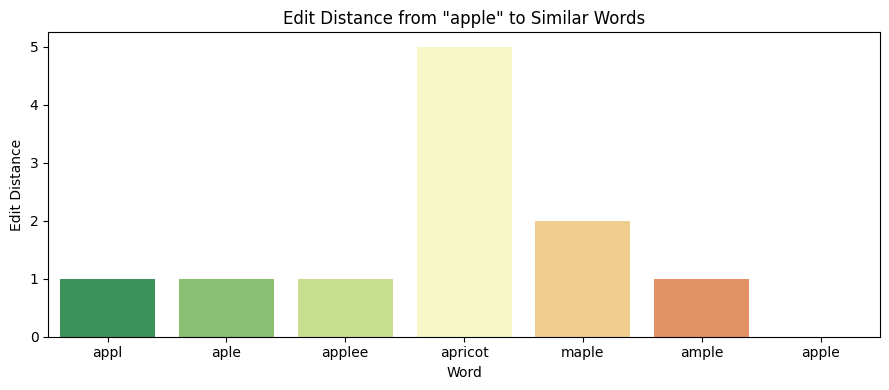

In [18]:
test_word = "apple"
similar_words = ["appl", "aple", "applee", "apricot", "maple", "ample", "apple"]
distances = [edit_distance(test_word, w) for w in similar_words]
plt.figure(figsize=(9, 4))
sns.barplot(x=similar_words, y=distances, palette='RdYlGn_r')
plt.title(f'Edit Distance from "{test_word}" to Similar Words')
plt.xlabel('Word')
plt.ylabel('Edit Distance')
plt.tight_layout()
plt.show()

**Autocomplete Coverage by Prefix Length**

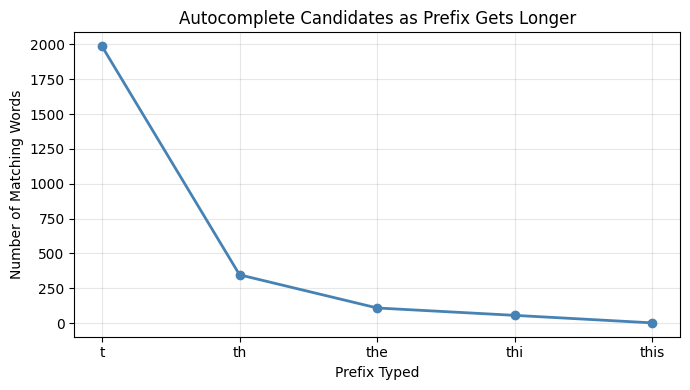

In [19]:
# How many words match as prefix length grows?
sample_prefixes = ["t", "th", "the", "thi", "this"]
coverage = []

for prefix in sample_prefixes:
    matches = [w for w in word_freq if w.startswith(prefix)]
    coverage.append(len(matches))

plt.figure(figsize=(7, 4))
plt.plot(sample_prefixes, coverage, marker='o', color='steelblue', linewidth=2)
plt.title('Autocomplete Candidates as Prefix Gets Longer')
plt.xlabel('Prefix Typed')
plt.ylabel('Number of Matching Words')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Measure Autocomplete Accuracy**

In [20]:
# Test: hide last word of a bigram, predict it, check if correct
correct = 0
total   = 500
test_bigrams = [(w1, w2) for (w1, w2), c in bigram_freq.most_common(500)]

for w1, actual_w2 in test_bigrams[:total]:
    predictions = autocomplete_bigram(w1, top_n=3)
    predicted_words = [p[0] for p in predictions]
    if actual_w2 in predicted_words:
        correct += 1

accuracy = round(correct / total * 100, 2)
print(f"Bigram Autocomplete Top-3 Accuracy: {accuracy}%")

Bigram Autocomplete Top-3 Accuracy: 50.4%


**Measure Autocorrect Accuracy**

In [23]:
# Known typo → correct word pairs
test_pairs = [
    ("recieve",  "receive"),
    ("occured",  "occurred"),
    ("teh",      "the"),
    ("adress",   "address"),
    ("comming",  "coming"),
    ("freind",   "friend"),
    ("wierd",    "weird"),
    ("beleive",  "believe"),
    ("calender", "calendar"),
    ("definately","definitely")
]

correct = 0
print(f"{'Typo':<15} {'Expected':<15} {'Got':<15} {'✓?'}")
print("-" * 55)
for typo, expected in test_pairs:
    got = spell.correction(typo)
    ok  = "right spelling" if got == expected else "wrong spelling"
    if got == expected: correct += 1
    print(f"{typo:<15} {expected:<15} {str(got):<15} {ok}")

print(f"\nAccuracy: {correct}/{len(test_pairs)} = {correct/len(test_pairs)*100}%")

Typo            Expected        Got             ✓?
-------------------------------------------------------
recieve         receive         receive         right spelling
occured         occurred        occurred        right spelling
teh             the             the             right spelling
adress          address         dress           wrong spelling
comming         coming          coming          right spelling
freind          friend          friend          right spelling
wierd           weird           weird           right spelling
beleive         believe         believe         right spelling
calender        calendar        calender        wrong spelling
definately      definitely      definitely      right spelling

Accuracy: 8/10 = 80.0%


**Speed Comparison: Unigram vs Bigram vs SpellChecker**

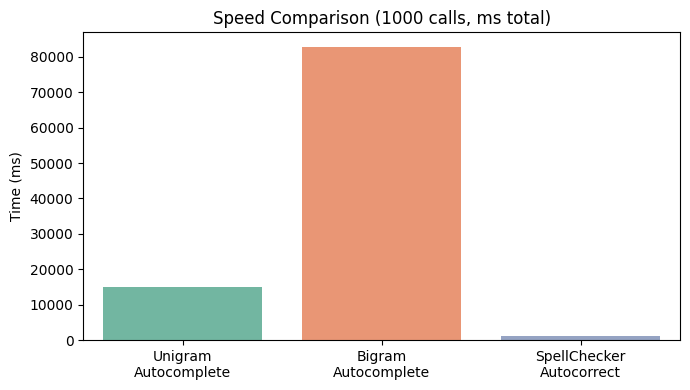

In [26]:
import time
prefix = "pro"
word   = "speling"
# Unigram autocomplete speed
start = time.time()
for _ in range(1000): autocomplete_unigram(prefix)
t1 = round((time.time() - start) * 1000, 2)
# Bigram autocomplete speed
start = time.time()
for _ in range(1000): autocomplete_bigram("the")
t2 = round((time.time() - start) * 1000, 2)
# SpellChecker speed
start = time.time()
for _ in range(1000): spell.correction(word)
t3 = round((time.time() - start) * 1000, 2)
methods = ['Unigram\nAutocomplete', 'Bigram\nAutocomplete', 'SpellChecker\nAutocorrect']
times   = [t1, t2, t3]

plt.figure(figsize=(7, 4))
sns.barplot(x=methods, y=times, palette='Set2')
plt.title('Speed Comparison (1000 calls, ms total)')
plt.ylabel('Time (ms)')
plt.tight_layout()
plt.show()

**TextBlob Sentiment + Autocorrect Demo**

In [27]:
# TextBlob can also autocorrect full sentences
sentences_to_fix = [
    "I luve programing in pythen",
    "Ths is an excelent exampl of NLP",
    "Speling errrors are annoyng"
]
print(f"{'Original':<40} {'Corrected'}")
print("-" * 80)
for s in sentences_to_fix:
    corrected = str(TextBlob(s).correct())
    print(f"{s:<40} {corrected}")

Original                                 Corrected
--------------------------------------------------------------------------------
I luve programing in pythen              I love programming in then
Ths is an excelent exampl of NLP         The is an excellent example of NLP
Speling errrors are annoyng              Feeling errors are annoying


**Word Cloud of Full Corpus**

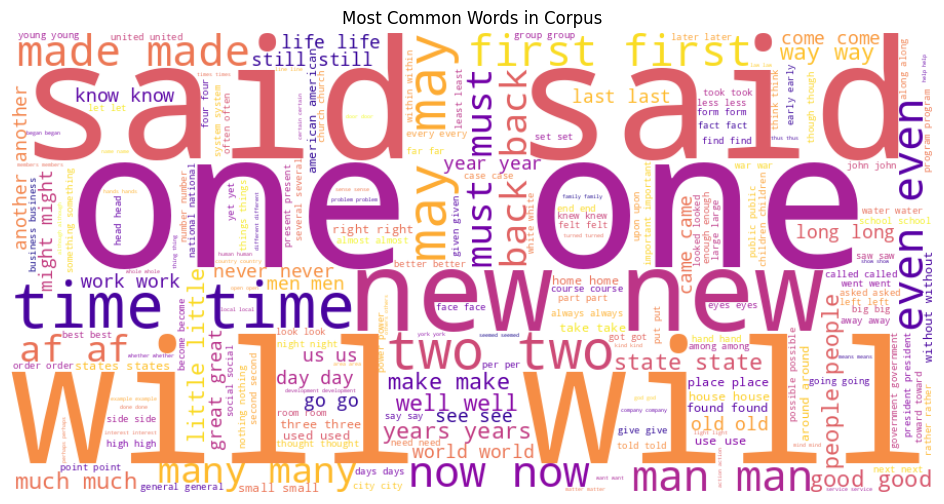

In [28]:
from wordcloud import WordCloud
text = ' '.join([w for w, c in word_freq.most_common(5000) for _ in range(min(c, 50))])

wc = WordCloud(width=900, height=450, background_color='white',
               colormap='plasma', max_words=200).generate(text)

plt.figure(figsize=(13, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Corpus')
plt.show()

**Final Summary Table**

In [29]:
summary = {
    "Total Words (corpus)":       len(clean_words),
    "Unique Words":                len(word_freq),
    "Total Bigrams":               len(bigrams),
    "Total Trigrams":              len(trigrams),
    "Vocab Size (spell checker)":  len(vocab),
    "Bigram Autocomplete Acc":     f"{accuracy}%",
}

print("=" * 45)
print("       PROJECT SUMMARY")
print("=" * 45)
for k, v in summary.items():
    print(f"  {k:<35} {v}")
print("=" * 45)

       PROJECT SUMMARY
  Total Words (corpus)                981716
  Unique Words                        40234
  Total Bigrams                       981715
  Total Trigrams                      981714
  Vocab Size (spell checker)          234375
  Bigram Autocomplete Acc             50.4%
